Neurons Keys: ['correlations_afv', 'correlations_incoherent', 'shc_afv', 'shc_coherent', 'shc_incoherent']


/opt/anaconda3/envs/np/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/var/folders/n2/4bsv95vs6x7gd_mllf2ytv6m0000gn/T/ipykernel_14528/2936581396.py:70: RuntimeWarning: invalid value encountered in sqrt
  IT_corrs_dyn = corrs_dyn / np.sqrt(spearmanbrown_correction(shc_norm) * spearmanbrown_correction(shc_dyn))
/var/folders/n2/4bsv95vs6x7gd_mllf2ytv6m0000gn/T/ipykernel_14528/2936581396.py:71: RuntimeWarning: invalid value encountered in sqrt
  IT_corrs_sta = corrs_sta / np.sqrt(spearmanbrown_correction(shc_norm) * spearmanbrown_correction(shc_sta))
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


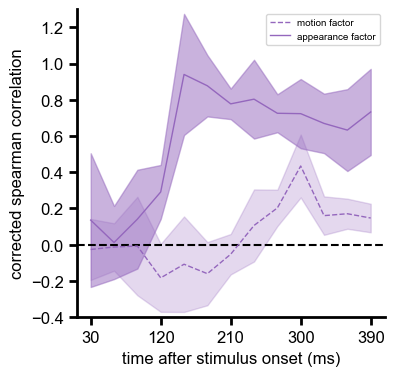

In [9]:
"""
Script: fig7_plot_static_dynamic_factors_IT.py
Description:
    This script analyzes and visualizes the static versus dynamic factors in IT neuron responses
    and compares them against various deep learning video models. It processes neural correlation
    scores from HDF5 files, applies statistical corrections, and generates figures.
Main Sections:
    1. Load and process IT neuron static/dynamic correlation scores with split-half corrections
    2. Plot IT neuron dynamic vs static factors with error bands across time bins
    3. Define static (repeated-frame) and dynamic (temporal) model architectures
    4. Process and aggregate model correlations, handling variable frame counts
    5. Compare neural vs model predictions in early and late response phases with histograms
Key Operations:
    - Loads correlation metrics from HDF5 files for neurons and models
    - Applies Spearman-Brown correction for split-half reliability
    - Computes median and standard error across neurons and time bins
    - Generates error band plots comparing static vs dynamic factors
    - Aggregates predictions across multiple model architectures
    - Creates comparison histograms showing model performance grouping by feature type
Output:
    Multiple publication-quality PDF figures showing:
    - IT neuron static/dynamic factor correlations over time
    - Model predictions for static and dynamic models separately
    - Early and late phase comparison histograms between neural and model data
"""

import sys
sys.path.append('../')

from utils.correlation_metrics import spearmanbrown_correction
import h5py
import numpy as np
import scipy.stats as stats

import matplotlib.pyplot as plt
from utils.plot_utils import journal_figure_pdf, journal_figure

import scienceplots

# Set the plotting style to 'nature' journal format
plt.style.use(['nature'])

# ============================================================================
# SECTION 1: Load and process IT neuron static/dynamic correlation scores
# ============================================================================

# Load correlation data from HDF5 file
scores_path = '../../scores/figure8'
neurons_file_path = f'{scores_path}/IT_correlations_static_dynamic_spearman.h5'
neurons_h5_file = h5py.File(neurons_file_path, 'r')
print("Neurons Keys:", list(neurons_h5_file.keys()))

# Extract correlations and split-half correction (shc) values from file
corrs_dyn = np.array(neurons_h5_file['correlations_afv'])
corrs_sta = np.array(neurons_h5_file['correlations_incoherent'])
shc_norm = np.array(neurons_h5_file['shc_coherent'])
shc_dyn = np.array(neurons_h5_file['shc_afv'])
shc_sta = np.array(neurons_h5_file['shc_incoherent'])



# Compute median across neurons (axis 0)
corrs_dyn = np.nanmedian(corrs_dyn, axis=0)
corrs_sta = np.nanmedian(corrs_sta, axis=0)
shc_norm = np.nanmedian(shc_norm, axis=0)
shc_dyn = np.nanmedian(shc_dyn, axis=0)
shc_sta = np.nanmedian(shc_sta, axis=0)

# Apply Spearman-Brown correction to account for split-half reliability
IT_corrs_dyn = corrs_dyn / np.sqrt(spearmanbrown_correction(shc_norm) * spearmanbrown_correction(shc_dyn))
IT_corrs_sta = corrs_sta / np.sqrt(spearmanbrown_correction(shc_norm) * spearmanbrown_correction(shc_sta))


# Compute mean and standard error across time bins
IT_corrs_dyn_mean = np.nanmedian(IT_corrs_dyn, axis=1)
IT_corrs_dyn_std = np.nanstd(IT_corrs_dyn, axis=1) / np.sqrt(IT_corrs_dyn.shape[1])

IT_corrs_sta_mean = np.nanmedian(IT_corrs_sta, axis=1)
IT_corrs_sta_std = np.nanstd(IT_corrs_sta, axis=1) / np.sqrt(IT_corrs_sta.shape[1])

# ============================================================================
# SECTION 2: Plot IT neuron dynamic vs static factors
# ============================================================================

plt.figure(figsize=(4, 4))
# Plot dynamic factor with error bands
plt.errorbar(range(IT_corrs_dyn_mean.shape[0]), IT_corrs_dyn_mean, 
            color='tab:purple',
            label='motion factor',
            linestyle='--')
plt.fill_between(range(IT_corrs_dyn_mean.shape[0]), 
                    IT_corrs_dyn_mean - IT_corrs_dyn_std, 
                    IT_corrs_dyn_mean + IT_corrs_dyn_std, 
                    color='tab:purple', alpha=0.25)

# Plot static factor with error bands
plt.errorbar(range(IT_corrs_sta_mean.shape[0]), IT_corrs_sta_mean, 
            color='tab:purple',
            label='appearance factor',
            linestyle='-')
plt.fill_between(range(IT_corrs_sta_mean.shape[0]), 
                    IT_corrs_sta_mean - IT_corrs_sta_std, 
                    IT_corrs_sta_mean + IT_corrs_sta_std, 
                    color='tab:purple', alpha=0.5)

# Add reference line at zero
plt.axhline(0.0, color='black', linestyle='--', linewidth=1.5)

# Create time labels (30ms bins) and subsample for cleaner x-axis
start_time = 0
bin_duration = 30
labels = [start_time + ((i+1) * bin_duration) for i in range(IT_corrs_sta_mean.shape[0])]
range_ = list(range(len(labels)))
labels = labels[::3]
range_ = range_[::3]

# Format axes and labels
plt.xticks(range_, labels, fontsize=10)
plt.legend(loc='upper right')
plt.xlabel("time after stimulus onset (ms)", fontsize=12)
plt.ylabel("corrected spearman correlation", fontsize=12)
plt.ylim([-0.4, 1.3])

# Save figure
journal_figure(do_save=True, filename=f'../../plots/figure8_static_dynamic_factors_IT.eps')
journal_figure_pdf(do_save=True, filename=f'../../plots/figure8_static_dynamic_factors_IT.pdf')
plt.show()



The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


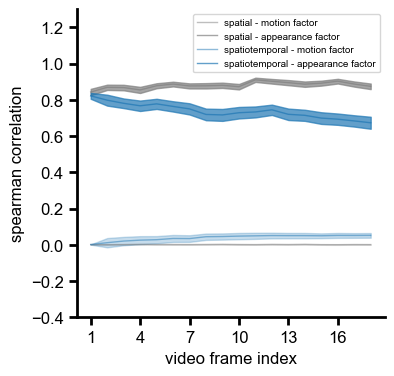

In [10]:

# ============================================================================
# SECTION 3: Define static and dynamic model architectures
# ============================================================================

# Models using static/repeated frame features
static_models = {
    "images_moving1_c2d_r50-blocks.4.res_blocks.5.activation_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:blue', 'C2D'], 
    "images_moving1_i3d_r50-blocks.5.res_blocks.2.activation_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:blue', 'I3D'], 
    "images_moving1_x3d_xs-blocks.4.res_blocks.6.activation_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:blue', 'X3D-XS'], 
    "images_moving1_sam2.1_hiera_b+-256-memory_attention-2_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:blue', 'SAM2'], 
    "images_moving1_slow_r50_ssv2-blocks.4.res_blocks.2.activation_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:blue', 'SlowR50-ssv2'], 
    "images_moving1_slow_r50-blocks.4.res_blocks.2.activation_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:blue', 'SlowR50'], 
    "images_moving1_timesformer_ssv2-timesformer.encoder.layer.8_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:blue', 'TimesFormer-ssv2'], 
    "images_moving1_timesformer-timesformer.encoder.layer.11_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:blue', 'TimesFormer'], 
    "images_moving1_videomamba_ssv2-layers.10.mixer_repeated-frame_features_srp-rgb2afv_1000_10.h5"  : ['f', 'tab:blue', 'VideoMamba-ssv2'], 
    "images_moving1_videomamba-layers.10.mixer_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:blue', 'VideoMamba'], 
    "images_moving1_videomae-videomae.encoder.layer.2_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:blue', 'VideoMAE'], 
    "images_moving1_matnet_fusion_type_gated-layer4,sensor_fusion_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:blue', 'MatNet-FUS'],
    "images_moving1_twostream_deeplabv3plus_resnet101_davis-layer4,sensor_fusion_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:blue', 'TSDLv3-FUS'],
    "images_moving1_vjepa2-encoder.layer.16.mlp.fc2_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:blue', 'V-JEPA2l'],
    "images_moving1_vjepa2g-encoder.layer.39.mlp.fc2_repeated-frame_features_srp-rgb2afv_1000_10.h5" : ['f', 'tab:blue', 'V-JEPA2g']
}

# Models using dynamic/temporal features across video frames
dynamic_models = {
    "images_moving1_c2d_r50-blocks.4.res_blocks.5.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'C2D'], 
    "images_moving1_i3d_r50-blocks.5.res_blocks.2.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'I3D'], 
    "images_moving1_x3d_xs-blocks.4.res_blocks.6.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'X3D-XS'], 
    "images_moving1_sam2.1_hiera_b+-256-memory_attention-2_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'SAM2'], 
    "images_moving1_slow_r50_ssv2-blocks.4.res_blocks.2.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'SlowR50-ssv2'], 
    "images_moving1_slow_r50-blocks.4.res_blocks.2.activation_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'SlowR50'], 
    "images_moving1_timesformer_ssv2-timesformer.encoder.layer.8_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer-ssv2'], 
    "images_moving1_timesformer-timesformer.encoder.layer.11_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'TimesFormer'], 
    "images_moving1_videomamba_ssv2-layers.10.mixer_features_srp-rgb2afv_1000_10.h5"  : ['d', 'tab:blue', 'VideoMamba-ssv2'], 
    "images_moving1_videomamba-layers.10.mixer_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'VideoMamba'], 
    "images_moving1_videomae-videomae.encoder.layer.2_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'VideoMAE'], 
    "images_moving1_matnet_fusion_type_gated-layer4,sensor_fusion_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'MatNet'],
    "images_moving1_twostream_deeplabv3plus_resnet101_davis-layer4,sensor_fusion_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'FusionSeg'],
    "images_moving1_vjepa2-encoder.layer.16.mlp.fc2_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'V-JEPA2l'],
    "images_moving1_vjepa2g-encoder.layer.39.mlp.fc2_features_srp-rgb2afv_1000_10.h5" : ['d', 'tab:blue', 'V-JEPA2g']
}

# ============================================================================
# SECTION 4: Process and plot model correlations
# ============================================================================

# Initialize storage for aggregated results

delta_model_early_values = []
delta_model_late_values = []
delta_model_early_values_all = []
delta_model_late_values_all = []

all_model_corrs_dyn = []
all_model_corrs_dyn_err = []
all_model_corrs_sta = []
all_model_corrs_sta_err = []

# Process static and dynamic models separately
for j, model_group in enumerate(['static_models', 'dynamic_models']):
    if model_group == 'static_models':
        model_color = 'tab:gray'
        models = static_models
    else:
        model_color = 'tab:blue'
        models = dynamic_models

    model_corrs_dyn = []
    model_corrs_sta = []
    
    # Load and aggregate correlations for each model
    for model in models.keys():
        neurons_file_path = f'{scores_path}/{model}/correlations_static_dynamic_spearman.h5'
        neurons_h5_file = h5py.File(neurons_file_path, 'r')
    
        # Extract dynamic and static factor correlations
        corrs_dyn = np.array(neurons_h5_file['correlations_afv'])
        corrs_dyn = np.nanmean(corrs_dyn, axis=0)
        corrs_dyn = np.nanmean(corrs_dyn, axis=-1)

        corrs_sta = np.array(neurons_h5_file['correlations_incoherent'])
        corrs_sta = np.nanmean(corrs_sta, axis=0)
        corrs_sta = np.nanmean(corrs_sta, axis=-1)
        
        
         # Calculate difference between static and dynamic factors
        delta = corrs_sta - corrs_dyn
        delta_model_early_values.append(np.nanmedian(delta[:, 1]))
        delta_model_late_values.append(np.nanmedian(delta[:, -2]))
        delta_model_early_values_all.append(delta[:, 1])
        delta_model_late_values_all.append(delta[:, -2])

        model_corrs_dyn.append(corrs_dyn)
        model_corrs_sta.append(corrs_sta)

    # Aggregate correlations across all models
    model_corrs_dyn = np.array(model_corrs_dyn)
    model_corrs_sta = np.array(model_corrs_sta)
    
    # Average across neurons and time bins
    #corrs_dyn = np.nanmean(model_corrs_dyn, axis=-1)
    model_corrs_dyn = np.nanmean(model_corrs_dyn, axis=2)
    corrs_dyn_mean = np.nanmedian(model_corrs_dyn, axis=0)
    corrs_dyn_std = np.nanstd(model_corrs_dyn, axis=0) / np.sqrt(model_corrs_dyn.shape[0])


    #corrs_sta = np.nanmean(model_corrs_sta, axis=-1)
    #corrs_sta = np.nanmean(corrs_sta, axis=2)
    model_corrs_sta = np.nanmean(model_corrs_sta, axis=2)
    corrs_sta_mean = np.nanmedian(model_corrs_sta, axis=0)
    corrs_sta_std = np.nanstd(model_corrs_sta, axis=0) / np.sqrt(model_corrs_dyn.shape[0])

    all_model_corrs_dyn.append(corrs_dyn_mean)
    all_model_corrs_dyn_err.append(corrs_dyn_std)
    all_model_corrs_sta.append(corrs_sta_mean)
    all_model_corrs_sta_err.append(corrs_sta_std)

     

# Plot model predictions
plt.figure(figsize=(4, 4))

for i in range(len(all_model_corrs_dyn)):
    corrs_dyn_mean = all_model_corrs_dyn[i]
    corrs_dyn_std = all_model_corrs_dyn_err[i]
    corrs_sta_mean = all_model_corrs_sta[i]
    corrs_sta_std = all_model_corrs_sta_err[i]
    model_color = 'tab:blue' if i == 1 else 'tab:gray'
    group_label = 'spatiotemporal' if i == 1 else 'spatial'
    plt.errorbar(range(18), corrs_dyn_mean, 
                color=model_color, label=f'{group_label} - motion factor', linestyle='-', alpha=0.5)
    plt.fill_between(range(18), 
                    corrs_dyn_mean - corrs_dyn_std, 
                    corrs_dyn_mean + corrs_dyn_std, 
                    color=model_color, alpha=0.25)

    plt.errorbar(range(18), corrs_sta_mean, 
                color=model_color, label=f'{group_label} - appearance factor', linestyle='-', alpha=0.7)
    plt.fill_between(range(18), 
                    corrs_sta_mean - corrs_sta_std, 
                    corrs_sta_mean + corrs_sta_std, 
                    color=model_color, alpha=0.7)

# Format x-axis with frame indices
labels = [i+1 for i in range(corrs_sta_mean.shape[0])]
range_ = list(range(len(labels)))
labels = labels[::3]
range_ = range_[::3]

plt.xticks(range_, labels, fontsize=10)
plt.legend(loc='upper right')
plt.ylim([-0.4, 1.3])
plt.xlabel("video frame index", fontsize=12)
plt.ylabel("spearman correlation", fontsize=12)

journal_figure(do_save=True, filename=f'../../plots/figure8_static_dynamic_factors_ANN.eps')
journal_figure_pdf(do_save=True, filename=f'../../plots/figure8_static_dynamic_factors_ANN.pdf')
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


spatial ANNs mean: 0.86 +- 0.06
Wilcoxon dynamic t-test: RanksumsResult(statistic=np.float64(0.5423261445466404), pvalue=np.float64(0.5875938479556577))
Wilcoxon dynamic t-test: WilcoxonResult(statistic=np.float64(34.0), pvalue=np.float64(0.15142822265625))
spatiotemporal ANNs mean: 0.70 +- 0.17
Wilcoxon dynamic t-test: RanksumsResult(statistic=np.float64(-0.5423261445466404), pvalue=np.float64(0.5875938479556577))
Wilcoxon dynamic t-test: WilcoxonResult(statistic=np.float64(15.0), pvalue=np.float64(0.00836181640625))
t-test dynamic vs. static: TtestResult(statistic=np.float64(-4.2150966038426345), pvalue=np.float64(0.0008647946047011644), df=np.int64(14))


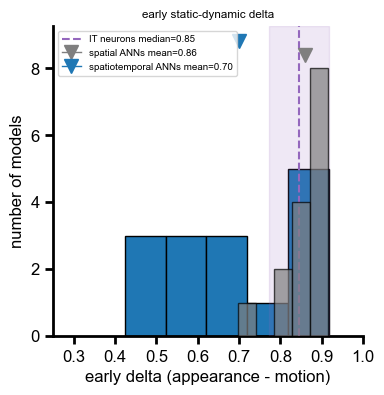

spatial ANNs mean: 0.88 +- 0.06
Wilcoxon dynamic t-test: RanksumsResult(statistic=np.float64(1.6269784336399213), pvalue=np.float64(0.10374167823654154))
Wilcoxon dynamic t-test: WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(6.103515625e-05))
spatiotemporal ANNs mean: 0.70 +- 0.16
Wilcoxon dynamic t-test: RanksumsResult(statistic=np.float64(1.6269784336399213), pvalue=np.float64(0.10374167823654154))
Wilcoxon dynamic t-test: WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(6.103515625e-05))
t-test dynamic vs. static: TtestResult(statistic=np.float64(-4.890316609523935), pvalue=np.float64(0.0002385722009371368), df=np.int64(14))


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


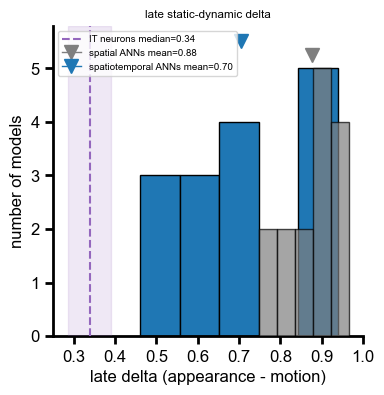

In [ ]:
import scipy
# ============================================================================
# SECTION 5: Analyze and visualize model comparison by early/late phases
# ============================================================================

# Compare neural vs model predictions in early and late response windows
for phase in ['early', 'late']:
    models = {**static_models, **dynamic_models}
    methods_names = list(models.keys())
    methods_labels = [models[m][2] for m in methods_names]

    # Select time window based on phase (early: 4, late: 9)
    if phase == 'early':
        delta_n = IT_corrs_sta[4] - IT_corrs_dyn[4]
        values = delta_model_early_values
    else:
        delta_n = IT_corrs_sta[9] - IT_corrs_dyn[9]
        values = delta_model_late_values

    # Calculate median absolute deviation for neural delta
    delta_n_mean = np.nanmedian(delta_n)
    absolute_deviations = np.abs(delta_n - delta_n_mean)
    delta_n_std = np.nanmedian(absolute_deviations) / np.sqrt(delta_n.shape[0])

    # Plot neural reference
    plt.figure(figsize=(4, 5))
    plt.axvline(delta_n_mean, color='tab:purple', linestyle='--', linewidth=1.5, zorder=3, label=f'IT neurons median={delta_n_mean:.2f}')
    plt.axvspan(delta_n_mean - delta_n_std, delta_n_mean + delta_n_std, color='tab:purple', alpha=0.15, zorder=3)

    # Group models by type and plot histograms
    type_order = ['f', 'ri', 'rv', 'd']
    groups = {t: [] for t in type_order}
    
    for name, label, val in zip(methods_names, methods_labels, values):
        t = models[name][0]
        # Normalize model type labels
        if t == 'ri':
            t = 'f'
        elif t == 'rv':
            t = 'd'
        if t not in groups:
            groups[t] = []
            type_order.append(t)
        groups[t].append((name, label, val))

    # Color scheme for model types
    type_color = {'f': 'tab:gray', 'd': 'tab:blue', 'ri': 'tab:orange', 'n': 'tab:purple'}

    # Plot histograms for each model type
    for idx, t in enumerate(type_order):
        items = groups.get(t, [])
        if not items:
            continue
        
        vals = [item[2] for item in items]
        names = [item[0] for item in items]
        type_label = 'spatiotemporal' if t == 'd' else 'spatial'
        plt.hist(vals, bins=5, color=type_color.get(t, 'tab:gray'), edgecolor='black', alpha=1.0 if t == 'd' else 0.7, zorder=3-idx+1)
        plt.plot(np.nanmean(vals), plt.ylim()[1] * 1.0, marker='v', color=type_color.get(t, 'tab:gray'), markersize=10, zorder=3-idx+1, label=f'{type_label} ANNs mean={np.nanmean(vals):.2f}')
        print(f"{type_label} ANNs mean: {np.nanmean(vals):.2f} +- {np.nanstd(vals):.2f}")
        print('Wilcoxon dynamic t-test:', stats.ranksums(vals, delta_n_mean))
        print('Wilcoxon dynamic t-test:', scipy.stats.wilcoxon(vals - delta_n_mean, alternative="two-sided"))

    print('t-test dynamic vs. static:', stats.ttest_rel([v[2] for v in groups['d']], [v[2] for v in groups['f']], nan_policy='omit'))

    plt.xlabel(f"{phase} delta (appearance - motion)", fontsize=12)
    plt.ylabel("number of models", fontsize=12)
    plt.yticks(fontsize=10)
    plt.xlim(0.25, 1.0)

    journal_figure(do_save=True, filename=f'../../plots/figure8_static_dynamic_factors_{phase}_ANN_histogram.eps')
    journal_figure_pdf(do_save=True, filename=f'../../plots/figure8_static_dynamic_factors_{phase}_ANN_histogram.pdf')
    plt.show()